# Histogramas e correção tonal

3 fotos

- `ft_escuro.png`
- `ft_clara.jpeg`
- `ft_eu_e_mae.jpeg`

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
arquivo = files.upload()

Saving ft_eu_e_mae.jpeg to ft_eu_e_mae.jpeg
Saving ft_escuro.png to ft_escuro.png
Saving ft_clara.jpeg to ft_clara.jpeg


### Funções da aula (adaptadas)

Troquei o loop pixel a pixel do `calHist` por `cv2.calcHist`, dá o mesmo histograma mas não trava com imagem grande.

In [3]:
def calcular_histograma(img_gray):
    return cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()


def plot_histograma(hist, titulo="Histograma", ax=None, cor="steelblue"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(256), hist, width=1, color=cor)
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Nº de pixels")
    ax.set_xlim(0, 255)
    return ax


def estatisticas_faixas(img_gray):
    hist = calcular_histograma(img_gray)
    total = hist.sum()
    baixa = hist[:64].sum() / total * 100
    media = hist[64:192].sum() / total * 100
    alta = hist[192:].sum() / total * 100
    return {
        "media": img_gray.mean(),
        "std": img_gray.std(),
        "min": int(img_gray.min()),
        "max": int(img_gray.max()),
        "%baixa_0_63": baixa,
        "%media_64_191": media,
        "%alta_192_255": alta,
    }


def expandir_contraste(img_gray, L, H):
    saida = (img_gray.astype(np.float32) - L) * (255.0 / (H - L))
    return np.clip(saida, 0, 255).astype(np.uint8)


def equalizar(img_gray):
    return cv2.equalizeHist(img_gray)


def corrigir_gamma(img_gray, gamma):
    tabela = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_gray, tabela)


def mostrar_antes_depois(antes, depois, titulo_antes, titulo_depois, titulo_fig=""):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(antes, cmap="gray", vmin=0, vmax=255)
    axs[0, 0].set_title(titulo_antes)
    axs[0, 0].axis("off")

    axs[0, 1].imshow(depois, cmap="gray", vmin=0, vmax=255)
    axs[0, 1].set_title(titulo_depois)
    axs[0, 1].axis("off")

    plot_histograma(calcular_histograma(antes), f"Histograma - {titulo_antes}", ax=axs[1, 0])
    plot_histograma(calcular_histograma(depois), f"Histograma - {titulo_depois}", ax=axs[1, 1], cor="darkorange")

    fig.suptitle(titulo_fig)
    plt.tight_layout()
    plt.show()

In [4]:
arquivos = {
    "escura": "ft_escuro.png",
    "clara": "ft_clara.jpeg",
    "bem_exposta": "ft_eu_e_mae.jpeg",
}

imagens_gray = {}
for nome, caminho in arquivos.items():
    img_bgr = cv2.imread(caminho)
    imagens_gray[nome] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

for nome, gray in imagens_gray.items():
    print(nome, estatisticas_faixas(gray))

escura {'media': np.float64(37.372597286082765), 'std': np.float64(19.86039030527942), 'min': 1, 'max': 245, '%baixa_0_63': np.float32(94.262085), '%media_64_191': np.float32(5.434563), '%alta_192_255': np.float32(0.30335313)}
clara {'media': np.float64(134.09912916666667), 'std': np.float64(55.388872175810874), 'min': 0, 'max': 255, '%baixa_0_63': np.float32(12.828125), '%media_64_191': np.float32(70.490486), '%alta_192_255': np.float32(16.681389)}
bem_exposta {'media': np.float64(149.47142760416668), 'std': np.float64(62.86887505184788), 'min': 0, 'max': 253, '%baixa_0_63': np.float32(9.13302), '%media_64_191': np.float32(49.143124), '%alta_192_255': np.float32(41.723854)}


## Foto escura (corredor)

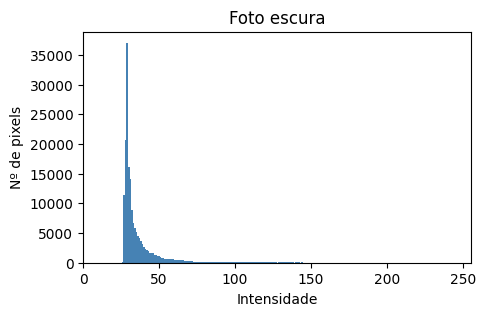

In [5]:
gray_escura = imagens_gray["escura"]
plot_histograma(calcular_histograma(gray_escura), "Foto escura")
plt.show()

94% dos pixels ficam entre 0 e 63, quase nada passa de 192. O histograma é um pico grudado na esquerda, imagem bem escura mesmo, sem quase nenhuma informação nos tons médios/altos.

Testei expansão de contraste primeiro mas não ajuda muito, porque o min/max já é quase 1-245 (a imagem já usa quase toda a faixa, só que concentrada embaixo). Fui de correção gamma, γ = 0.4, que puxa os tons escuros pra cima sem estourar o que já é claro.

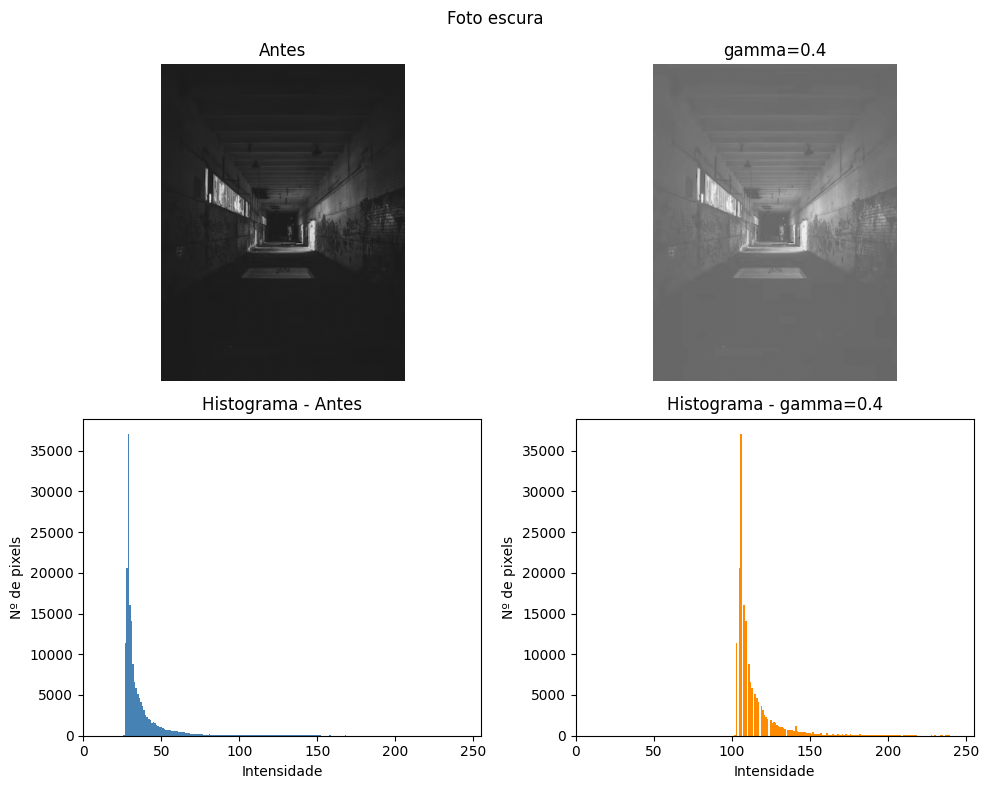

antes: {'media': np.float64(37.372597286082765), 'std': np.float64(19.86039030527942), 'min': 1, 'max': 245, '%baixa_0_63': np.float32(94.262085), '%media_64_191': np.float32(5.434563), '%alta_192_255': np.float32(0.30335313)}
depois: {'media': np.float64(115.51151171918806), 'std': np.float64(17.899927319403467), 'min': 27, 'max': 250, '%baixa_0_63': np.float32(0.01009308), '%media_64_191': np.float32(98.72042), '%alta_192_255': np.float32(1.2694852)}


In [6]:
gamma_escura = 0.4
escura_corrigida = corrigir_gamma(gray_escura, gamma_escura)

mostrar_antes_depois(gray_escura, escura_corrigida, "Antes", f"gamma={gamma_escura}", "Foto escura")

print("antes:", estatisticas_faixas(gray_escura))
print("depois:", estatisticas_faixas(escura_corrigida))

## Foto clara (rio, contraluz)

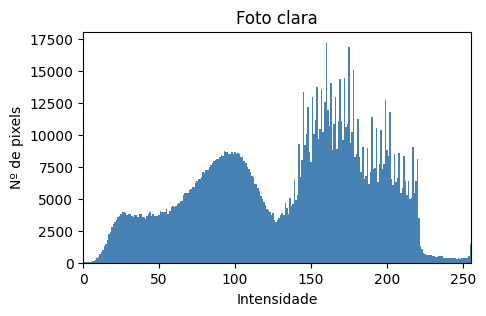

In [7]:
gray_clara = imagens_gray["clara"]
plot_histograma(calcular_histograma(gray_clara), "Foto clara")
plt.show()

 quase não tem preto de verdade na foto, é isso que dá aquela cara meio lavada/enevoada. Mas não tem clipping forte em 255, então não é bem "estourada", é mais falta de contraste.

Usei expansão de contraste com L=20, H=235 pra forçar uns pretos e brancos reais e recuperar contraste.

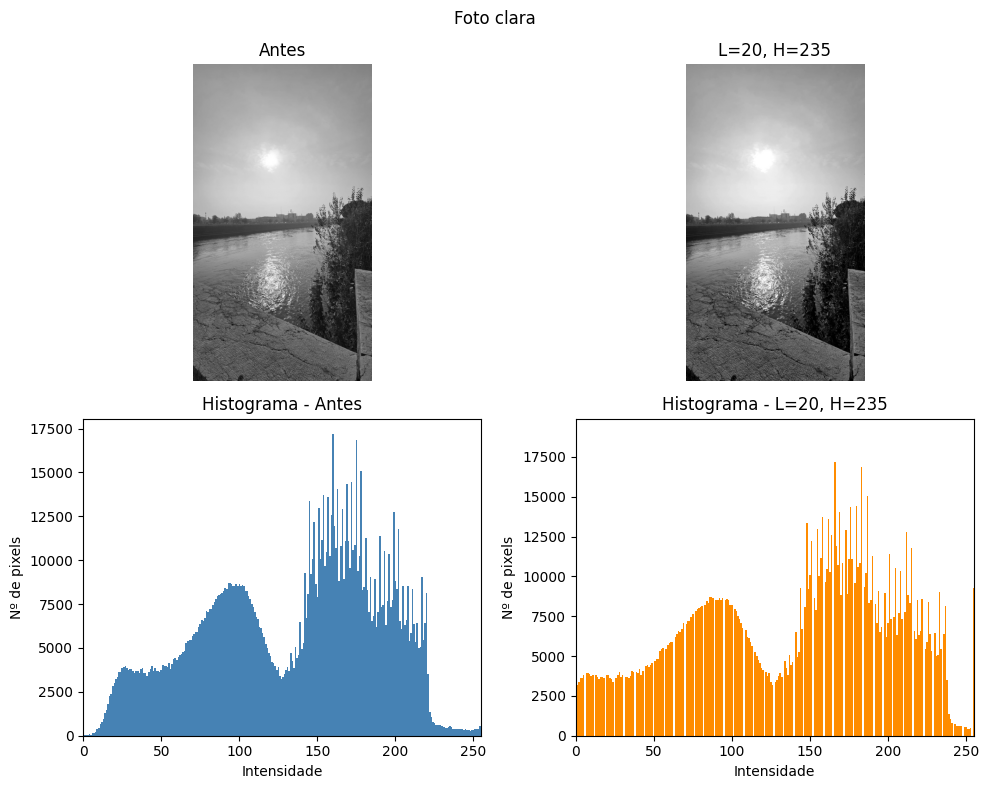

antes: {'media': np.float64(134.09912916666667), 'std': np.float64(55.388872175810874), 'min': 0, 'max': 255, '%baixa_0_63': np.float32(12.828125), '%media_64_191': np.float32(70.490486), '%alta_192_255': np.float32(16.681389)}
depois: {'media': np.float64(134.8246347222222), 'std': np.float64(65.3909358721954), 'min': 0, 'max': 255, '%baixa_0_63': np.float32(16.617847), '%media_64_191': np.float32(61.240345), '%alta_192_255': np.float32(22.141806)}


In [8]:
L_clara, H_clara = 20, 235
clara_corrigida = expandir_contraste(gray_clara, L_clara, H_clara)

mostrar_antes_depois(gray_clara, clara_corrigida, "Antes", f"L={L_clara}, H={H_clara}", "Foto clara")

print("antes:", estatisticas_faixas(gray_clara))
print("depois:", estatisticas_faixas(clara_corrigida))

## Foto bem exposta (praia)

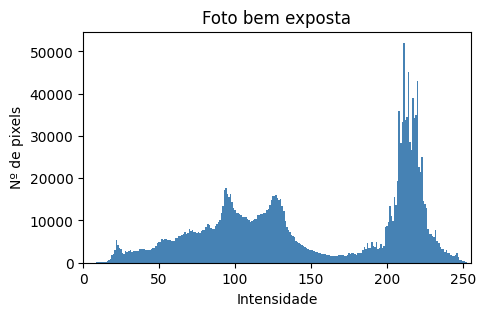

In [9]:
gray_boa = imagens_gray["bem_exposta"]
plot_histograma(calcular_histograma(gray_boa), "Foto bem exposta")
plt.show()

Aqui a distribuição já cobre quase tudo (0 a 253), std alto (63), sem pico grudado em nenhuma ponta. Tem uma concentração na faixa alta por causa do céu, mas nada de clipping. É basicamente o histograma "de livro" de uma foto bem exposta.

Como já está ok, apliquei equalização só pra ver o quanto ela muda uma imagem que, na prática, não precisava de correção.

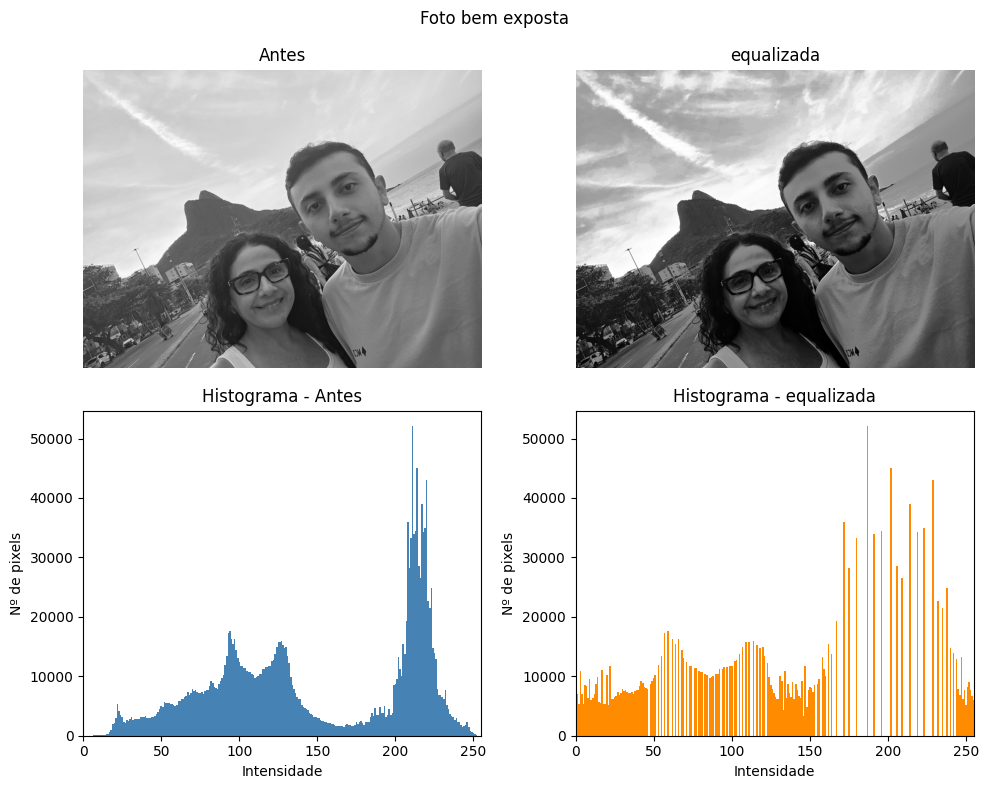

antes: {'media': np.float64(149.47142760416668), 'std': np.float64(62.86887505184788), 'min': 0, 'max': 253, '%baixa_0_63': np.float32(9.13302), '%media_64_191': np.float32(49.143124), '%alta_192_255': np.float32(41.723854)}
depois: {'media': np.float64(128.64586666666668), 'std': np.float64(74.09525427616055), 'min': 0, 'max': 255, '%baixa_0_63': np.float32(24.13448), '%media_64_191': np.float32(50.827915), '%alta_192_255': np.float32(25.037605)}


In [10]:
boa_corrigida = equalizar(gray_boa)

mostrar_antes_depois(gray_boa, boa_corrigida, "Antes", "equalizada", "Foto bem exposta")

print("antes:", estatisticas_faixas(gray_boa))
print("depois:", estatisticas_faixas(boa_corrigida))

## Diferença antes/depois

In [11]:
def diferenca_media(antes, depois):
    return np.mean(np.abs(antes.astype(int) - depois.astype(int)))

print("escura (gamma):", diferenca_media(gray_escura, escura_corrigida))
print("clara (expansão):", diferenca_media(gray_clara, clara_corrigida))
print("bem exposta (equalização):", diferenca_media(gray_boa, boa_corrigida))

escura (gamma): 78.1389144331053
clara (expansão): 8.833813888888889
bem exposta (equalização): 24.443630729166667


### Em qual foto a operação fez menos diferença?

Foi na foto clara (diferença média ~9, contra ~24 na bem exposta e ~78 na escura). Faz sentido: apesar de eu ter escolhido ela como "clara demais", o histograma já ocupava quase toda a faixa 0-255 e não tinha clipping de verdade,o problema era mais visual (parecer lavada, sem pretos) do que estatístico, esticar um intervalo que já é quase o total não muda muita coisa. Já a foto escura, com quase todo mundo espremido entre 0 e 63, precisou de uma correção bem mais forte pra trazer detalhe de volta, por isso a diferença é  maior.